# Data Loading and Library Import

In [78]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, StratifiedKFold

from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

from sklearn.preprocessing import StandardScaler, LabelEncoder
from scipy.stats import boxcox

from sklearn.metrics import (accuracy_score, balanced_accuracy_score, f1_score,
                              fbeta_score, confusion_matrix, precision_score, recall_score)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
import xgboost as xgb


from imblearn.over_sampling import SMOTE, SMOTENC
from imblearn.under_sampling import EditedNearestNeighbours, TomekLinks

import optuna

import joblib
RANDOM_STATE = 67

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('filtered_data.csv')

In [4]:
df.head()

,_BMI5,_BMI5CAT,_AGE_G,_AGE80,_AGE65YR,_INCOMG1,INCOME3,_SMOKER3,_RFSMOK3,SMOKDAY2,...,MENTHLTH,ADDEPEV3,LANDSEX3,SEXVAR,DIABETE4,PERSDOC3,PRIMINS2,_URBSTAT,_IMPRACE,CHILDREN
0,2249.0,2.0,6.0,78.0,2.0,9.0,99.0,4.0,1.0,NaN,...,88.0,2.0,2.0,2.0,3.0,2.0,3.0,1.0,1.0,88.0
1,2583.0,3.0,6.0,80.0,2.0,7.0,11.0,3.0,1.0,3.0,...,88.0,2.0,1.0,1.0,3.0,1.0,3.0,1.0,1.0,88.0
2,2253.0,2.0,5.0,59.0,1.0,9.0,99.0,1.0,2.0,1.0,...,88.0,2.0,1.0,1.0,3.0,3.0,1.0,1.0,1.0,88.0
3,2509.0,3.0,6.0,80.0,2.0,4.0,6.0,4.0,1.0,NaN,...,88.0,2.0,1.0,1.0,3.0,1.0,3.0,1.0,1.0,88.0
4,1977.0,2.0,4.0,47.0,1.0,2.0,3.0,4.0,1.0,NaN,...,88.0,2.0,1.0,1.0,3.0,1.0,5.0,1.0,1.0,88.0


In [5]:
df.shape

(457670, 33)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 457670 entries, 0 to 457669
Data columns (total 33 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   _BMI5     414633 non-null  float64
 1   _BMI5CAT  414633 non-null  float64
 2   _AGE_G    457670 non-null  float64
 3   _AGE80    457670 non-null  float64
 4   _AGE65YR  457670 non-null  float64
 5   _INCOMG1  457670 non-null  float64
 6   INCOME3   448401 non-null  float64
 7   _SMOKER3  457670 non-null  float64
 8   _RFSMOK3  457670 non-null  float64
 9   SMOKDAY2  167076 non-null  float64
 10  CVDINFR4  457668 non-null  float64
 11  CVDCRHD4  457667 non-null  float64
 12  ASTHMA3   457667 non-null  float64
 13  _LTASTH1  457670 non-null  float64
 14  CHCKDNY2  457664 non-null  float64
 15  MARITAL   457661 non-null  float64
 16  EDUCA     457663 non-null  float64
 17  _EDUCAG   457670 non-null  float64
 18  GENHLTH   457665 non-null  float64
 19  EXERANY2  457667 non-null  float64
 20  _TOTINDA  45767

In [7]:
chosen_columns = ['_BMI5', '_AGE_G', 'INCOME3', '_SMOKER3', 'CVDINFR4', 'CVDCRHD4',
                 'ASTHMA3', 'CHCKDNY2', 'MARITAL', 'EDUCA', 'GENHLTH', 'EXERANY2',
                 'HAVARTH4', 'MENTHLTH', 'ADDEPEV3', 'PRIMINS2', '_URBSTAT', 'CHILDREN', 'DIABETE4', 'SEXVAR']

df = df[chosen_columns]

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 457670 entries, 0 to 457669
Data columns (total 20 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   _BMI5     414633 non-null  float64
 1   _AGE_G    457670 non-null  float64
 2   INCOME3   448401 non-null  float64
 3   _SMOKER3  457670 non-null  float64
 4   CVDINFR4  457668 non-null  float64
 5   CVDCRHD4  457667 non-null  float64
 6   ASTHMA3   457667 non-null  float64
 7   CHCKDNY2  457664 non-null  float64
 8   MARITAL   457661 non-null  float64
 9   EDUCA     457663 non-null  float64
 10  GENHLTH   457665 non-null  float64
 11  EXERANY2  457667 non-null  float64
 12  HAVARTH4  457665 non-null  float64
 13  MENTHLTH  457667 non-null  float64
 14  ADDEPEV3  457665 non-null  float64
 15  PRIMINS2  457667 non-null  float64
 16  _URBSTAT  443047 non-null  float64
 17  CHILDREN  452064 non-null  float64
 18  DIABETE4  457666 non-null  float64
 19  SEXVAR    457670 non-null  float64
dtypes: float64(20)


# Data Cleaning

We're gonna be starting with simple value remapping. From the data's dictionary, we found out that there is some columns that are encoded weirdly, so we will be manually remapping those weird columns with a more proper values. Since these changes are rather independent, we will be doing it directly without splitting first since there's no data leak potential. Here are the list of changes that we made:

- Most of the binary column were mapped with 1 for yes, and 2 for no. To create a proper binary column, we've remapped them to the usual 0 for no and 1 for yes.
- Most categorical column uses 7/77 for don't know or not sure, 8/88 for 0, and 9/99 for refused, so we've swapped them with NaN values so that we can impute them with the previously stated reason above.
- Column GENHLTH's ordinality is reversed, where 1 was for excellent health while 5 was for poor health. In order to give the ordinality real meaning we've reversed| the order of the value.
- DIABETE4 has 4 categories, which were Diabetic, Pregnancy-related Diabetic, Pre-Diabetic, and Non-Diabetic. We are gonna me removing the pregnancy-related one since it is very specific and usually dissapear after pregnancy is done. And then since we are creating an early warning system, we have decided that we are going to merge Diabetic and Pre-Diabetic.
- _BMI5 was for whatever reason stored after it has been multiplied by 100. I'm assuming this happened because they might need to get rid of floating points value for the specific XPT format. To get the original value back, we will be dividing this column with 100.

In [9]:
def map_df(df):
    df['DIABETE4'] = df['DIABETE4'].map({
        1: 1, 2: np.nan, 3: 0, 4: 1, 7: np.nan, 9: np.nan
    })

    # Binary columns
    binary_cols = [
        'EXERANY2', 'CVDINFR4', 'CVDCRHD4',
        'ASTHMA3', 'CHCKDNY2', 'HAVARTH4', 'ADDEPEV3'
    ]
    binary_map = {1: 1, 2: 0, 7: np.nan, 9: np.nan}
    for col in binary_cols:
        df[col] = df[col].map(binary_map)

    # Age
    df['_AGE_G'] = df['_AGE_G'].map({1:1, 2:2, 3:3, 4:4, 5:5, 6:6})

    # Income
    df['INCOME3'] = df['INCOME3'].replace({77: np.nan, 99: np.nan})

    # General Health
    df['GENHLTH'] = df['GENHLTH'].map({1:5, 2:4, 3:3, 4:2, 5:1, 7:np.nan, 9:np.nan})

    # Education
    df['EDUCA'] = df['EDUCA'].replace({9: np.nan})

    # Sex
    df['SEXVAR'] = df['SEXVAR'].map({1:0, 2:1})

    # Urban/Rural
    df['_URBSTAT'] = df['_URBSTAT'].map({1:0, 2:1})

    # Nominal columns
    nominal_cols = ['MARITAL', 'PRIMINS2', '_SMOKER3']
    for col in nominal_cols:
        df[col] = df[col].replace({7: np.nan, 9: np.nan, 77: np.nan, 99: np.nan})

    # BMI scaling
    df['_BMI5'] = df['_BMI5'] / 100.0

    # Children
    df['CHILDREN'] = df['CHILDREN'].replace({88: 0, 99: np.nan})

    # Mental health
    df['MENTHLTH'] = df['MENTHLTH'].replace({88: 0, 77: np.nan, 99: np.nan})

    return df

In [10]:
df_mapped = map_df(df)

df_mapped

,_BMI5,_AGE_G,INCOME3,_SMOKER3,CVDINFR4,CVDCRHD4,ASTHMA3,CHCKDNY2,MARITAL,EDUCA,GENHLTH,EXERANY2,HAVARTH4,MENTHLTH,ADDEPEV3,PRIMINS2,_URBSTAT,CHILDREN,DIABETE4,SEXVAR
0,22.49,6,NaN,4.0,0.0,0.0,0.0,0.0,3.0,4.0,3.0,1.0,1.0,0.0,0.0,3.0,0.0,0.0,0.0,1
1,25.83,6,11.0,3.0,0.0,1.0,0.0,0.0,1.0,6.0,5.0,1.0,1.0,0.0,0.0,3.0,0.0,0.0,0.0,0
2,22.53,5,NaN,1.0,0.0,0.0,0.0,0.0,6.0,5.0,4.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0
3,25.09,6,6.0,4.0,0.0,0.0,0.0,0.0,1.0,6.0,5.0,1.0,1.0,0.0,0.0,3.0,0.0,0.0,0.0,0
4,19.77,4,3.0,4.0,0.0,0.0,0.0,0.0,5.0,5.0,3.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
457665,NaN,6,NaN,NaN,0.0,0.0,0.0,0.0,1.0,2.0,NaN,1.0,0.0,2.0,0.0,3.0,NaN,NaN,0.0,0
457666,20.66,6,6.0,1.0,0.0,0.0,0.0,0.0,5.0,2.0,2.0,0.0,0.0,1.0,NaN,88.0,NaN,0.0,0.0,0
457667,24.37,6,8.0,4.0,0.0,0.0,1.0,0.0,5.0,6.0,3.0,0.0,0.0,0.0,0.0,1.0,NaN,0.0,1.0,0
457668,24.41,4,10.0,3.0,0.0,0.0,0.0,0.0,1.0,5.0,5.0,1.0,0.0,0.0,0.0,2.0,NaN,0.0,0.0,0


Next, we will be handling the missing values. It has been analyzed before from EDA_Modelling that we have a clear case of MNAR/MAR missing values. Because of that, we have decided that we will not be dropping those columns since the same pattern may appear on an actual real-world case. So, we have experimented with some techniques, and the summarized technique below yielded the best result for us:

- Simple Median/Mode Imputer on column that only has <5% missing values. We are keeping it simple for these columns since small amount of static imputation won't really ruin the original distribution.
- RF Imputer + XGB Selected Features on column that has >5% missing values. We decided to do this because imputing these columns with static imputer will create a massive spike in the distribution, which may make the model not perform as well as it would've on a normally distributed data.

Since these technique has a data leak potential, we will be splitting the data first before performing it.

In [11]:
df_mapped.shape

(457670, 20)

In [12]:
df_mapped.isna().sum()

_BMI5       43037
_AGE_G          0
INCOME3     87423
_SMOKER3    32022
CVDINFR4     3115
CVDCRHD4     4578
ASTHMA3      1861
CHCKDNY2     1979
MARITAL      4222
EDUCA        2363
GENHLTH      1310
EXERANY2     1315
HAVARTH4     2573
MENTHLTH     8156
ADDEPEV3     2664
PRIMINS2    47812
_URBSTAT    14623
CHILDREN     9379
DIABETE4     4429
SEXVAR          0
dtype: int64

In [13]:
df_mapped = df_mapped.dropna(subset=['DIABETE4'])

df_train, df_test = train_test_split(df_mapped, test_size=0.2, random_state=RANDOM_STATE, stratify=df_mapped['DIABETE4'])

df_train.shape, df_test.shape

((362592, 20), (90649, 20))

In [14]:
display(df_train.isna().sum())
print()
display(df_test.isna().sum())

_BMI5       33699
_AGE_G          0
INCOME3     69153
_SMOKER3    25295
CVDINFR4     2269
CVDCRHD4     3387
ASTHMA3      1305
CHCKDNY2     1374
MARITAL      3260
EDUCA        1802
GENHLTH       974
EXERANY2      978
HAVARTH4     1801
MENTHLTH     6360
ADDEPEV3     1909
PRIMINS2    37882
_URBSTAT    11605
CHILDREN     7306
DIABETE4        0
SEXVAR          0
dtype: int64

_BMI5        8549
_AGE_G          0
INCOME3     17175
_SMOKER3     6269
CVDINFR4      632
CVDCRHD4      920
ASTHMA3       335
CHCKDNY2      372
MARITAL       803
EDUCA         438
GENHLTH       268
EXERANY2      256
HAVARTH4      468
MENTHLTH     1608
ADDEPEV3      502
PRIMINS2     9387
_URBSTAT     2891
CHILDREN     1885
DIABETE4        0
SEXVAR          0
dtype: int64

In [15]:
def predictive_impute(train_df, test_df, target_col, feature_cols, categorical_model, regression_model, is_categorical=True):
    train_df = train_df.copy()
    test_df = test_df.copy()

    known = train_df[train_df[target_col].notna()]
    unknown = train_df[train_df[target_col].isna()]

    model = categorical_model if is_categorical else regression_model
    le = LabelEncoder() if is_categorical else None

    if unknown.shape[0] > 0:
        X_known = known[feature_cols].copy()
        y_known = known[target_col]
        X_unknown = unknown[feature_cols].copy()

        # Encode categoricals as integers
        for col in X_known.columns:
            if X_known[col].dtype == 'object' or X_known[col].dtype.name == 'category':
                cats = list(X_known[col].dropna().unique())
                mapping = {k:i for i,k in enumerate(cats)}
                X_known[col] = X_known[col].map(mapping)
                X_unknown[col] = X_unknown[col].map(mapping)

        #  target encoding for xgberror
        if is_categorical:
            y_train_encoded = le.fit_transform(y_known)
        else:
            y_train_encoded = y_known

        #  TRAIN MODEL
        model.fit(X_known, y_train_encoded)

        #  PREDICT & DECODE
        preds = model.predict(X_unknown)
        if is_categorical:
            preds = le.inverse_transform(preds)

        train_df.loc[train_df[target_col].isna(), target_col] = preds

    # PREDICT MISSING IN TEST
    test_unknown = test_df[test_df[target_col].isna()]
    if test_unknown.shape[0] > 0:
        X_test_unknown = test_unknown[feature_cols].copy()
        for col in X_test_unknown.columns:
            if X_test_unknown[col].dtype == 'object' or X_test_unknown[col].dtype.name == 'category':
                # Gunakan mapping dari train untuk konsistensi
                cats = list(known[col].dropna().unique())
                mapping = {k:i for i,k in enumerate(cats)}
                X_test_unknown[col] = X_test_unknown[col].map(mapping)

        test_preds = model.predict(X_test_unknown)
        if is_categorical:
            test_preds = le.inverse_transform(test_preds)

        test_df.loc[test_df[target_col].isna(), target_col] = test_preds

    return train_df[target_col], test_df[target_col]

def rf_impute(df_train, df_test):
    """
    Train/test-safe imputation:
    - Simple imputation (median/mode) for most columns
    - Predictive imputation for tricky columns (_BMI5, INCOME3, _SMOKER3)
    """
    df_train = df_train.copy()
    df_test = df_test.copy()

    # --- 1. Columns by type for simple imputation ---
    numeric_cols = ['CHILDREN', 'MENTHLTH']  # median only
    ordinal_mode_cols = ['_AGE_G', 'GENHLTH', 'EDUCA']  # mode only
    cat_mode_cols = [
        'MARITAL', 'SEXVAR', 'PRIMINS2',
        '_URBSTAT', 'EXERANY2', 'CVDINFR4', 'CVDCRHD4', 'ASTHMA3',
        'CHCKDNY2', 'HAVARTH4', 'ADDEPEV3'
    ]  # mode only

    # --- 2. Simple imputation ---
    # Numeric
    num_imputer = SimpleImputer(strategy='median')
    df_train[numeric_cols] = num_imputer.fit_transform(df_train[numeric_cols])
    df_test[numeric_cols] = num_imputer.transform(df_test[numeric_cols])

    # Ordinal
    ord_imputer = SimpleImputer(strategy='most_frequent')
    df_train[ordinal_mode_cols] = ord_imputer.fit_transform(df_train[ordinal_mode_cols])
    df_test[ordinal_mode_cols] = ord_imputer.transform(df_test[ordinal_mode_cols])

    # Categorical
    cat_imputer = SimpleImputer(strategy='most_frequent')
    df_train[cat_mode_cols] = cat_imputer.fit_transform(df_train[cat_mode_cols])
    df_test[cat_mode_cols] = cat_imputer.transform(df_test[cat_mode_cols])

    # --- 3. Apply predictive imputation on tricky columns ---
    categorical_model = RandomForestClassifier(random_state=RANDOM_STATE)
    regression_model = RandomForestRegressor(random_state=RANDOM_STATE)
    # INCOME3 -> categorical
    df_train['INCOME3'], df_test['INCOME3'] = predictive_impute(
        df_train, df_test, 'INCOME3',
        ['PRIMINS2', 'EDUCA', 'MARITAL', 'GENHLTH', '_AGE_G', 'EXERANY2', 'SEXVAR', '_URBSTAT'],
        categorical_model, regression_model, is_categorical=True,
    )

    # _BMI5 -> numeric
    df_train['_BMI5'], df_test['_BMI5'] = predictive_impute(
        df_train, df_test, '_BMI5',
        ['GENHLTH', 'EXERANY2', 'HAVARTH4', '_AGE_G', 'ASTHMA3', '_SMOKER3'],
        categorical_model, regression_model, is_categorical=False
    )

    # _SMOKER3 -> categorical
    df_train['_SMOKER3'], df_test['_SMOKER3'] = predictive_impute(
        df_train, df_test, '_SMOKER3',
        ['_AGE_G', 'EDUCA', 'ADDEPEV3', 'SEXVAR', 'HAVARTH4'],
        categorical_model, regression_model, is_categorical=True
    )

    return df_train, df_test

In [16]:
df_train_imputed, df_test_imputed = rf_impute(df_train, df_test)

display(df_train_imputed.isna().sum())
print()
display(df_test_imputed.isna().sum())

_BMI5       0
_AGE_G      0
INCOME3     0
_SMOKER3    0
CVDINFR4    0
CVDCRHD4    0
ASTHMA3     0
CHCKDNY2    0
MARITAL     0
EDUCA       0
GENHLTH     0
EXERANY2    0
HAVARTH4    0
MENTHLTH    0
ADDEPEV3    0
PRIMINS2    0
_URBSTAT    0
CHILDREN    0
DIABETE4    0
SEXVAR      0
dtype: int64

_BMI5       0
_AGE_G      0
INCOME3     0
_SMOKER3    0
CVDINFR4    0
CVDCRHD4    0
ASTHMA3     0
CHCKDNY2    0
MARITAL     0
EDUCA       0
GENHLTH     0
EXERANY2    0
HAVARTH4    0
MENTHLTH    0
ADDEPEV3    0
PRIMINS2    0
_URBSTAT    0
CHILDREN    0
DIABETE4    0
SEXVAR      0
dtype: int64

Nice, now that the data already has 0 missing values, let's move on to preprocessing now.

# Data Preprocessing

The data preprocessing part is mainly going to be split into two parts, which are encoding and feature engineering.

##### 1. Encoding
The encoding scheme is actually going to be really simple. We will only be applying one-hot encoding to the nominal columns. We don't really need to apply anything else since the binary and ordinal columns are either already correct or have been fixed in the mapping part earlier.

##### 2. Feature Engineering
All of our feature engineering will be based on EDA that we've made before. There are 3 feature engineering that we are gonna be applying, which are:

1. BoxCox Transform + Standard Scaling on _BMI5: The reason for this is that because _BMI5 column was initially highly skewed with a value of 1.42. After trying some transformation methods, we've found out that boxcox transform had the best result, lowering the skewness all the way to -0.01. This, however come with a trade-off where the data range is now very small, ranging from 1.3 to 1.6 only. This could be dangerous for the linear model, so we've decided to also apply standard scaling in order to compensate for this.

2. Merging CHILDREN column: The CHILDREN column had a very strange outliers, where its showing that some families could have as many as 20+ childrens, with the most being 83 children. Luckily the amount of these strange numbers are very low, so we've decided to merge them into a 4+ category based on the elbow analysis that we did in the EDA.

3. (EXPERIMENTAL) Hurdle Preprocessing MENTHLTH Column: We've decided to create a new binary 'is_menthlth' flag in order to give the model a new signal whether the sample has mental health problem or not. This was inspired by most of hurdle model articles that states that the zero data in zero-inflated data usually may have a strong signal on its own.  

In [17]:
def one_hot_encode_nominal(df_train, df_test):
    """
    One-Hot Encodes nominal columns after imputation is complete.
    Combines train and test sets temporarily to ensure the dummy columns align perfectly.
    """
    # The columns that have no mathematical order
    nominal_cols = ['MARITAL', 'PRIMINS2', '_SMOKER3']

    df_train = df_train.copy()
    df_test = df_test.copy()

    df_train['is_train_set'] = 1
    df_test['is_train_set'] = 0

    combined_df = pd.concat([df_train, df_test])

    # Apply One-Hot Encoding (drop_first=True prevents multicollinearity for LR/SVM)
    combined_encoded = pd.get_dummies(combined_df, columns=nominal_cols, drop_first=True)

    df_train_encoded = combined_encoded[combined_encoded['is_train_set'] == 1].drop(columns=['is_train_set'])
    df_test_encoded = combined_encoded[combined_encoded['is_train_set'] == 0].drop(columns=['is_train_set'])

    return df_train_encoded, df_test_encoded

In [18]:
df_train_encoded, df_test_encoded = one_hot_encode_nominal(df_train_imputed, df_test_imputed)

df_train_encoded.shape, df_test_encoded.shape

((362592, 33), (90649, 33))

In [19]:
def fe_data(df_train, df_test):
    df_tr = df_train.copy()
    df_te = df_test.copy()

    # use the same lambda to avoid data leak.
    df_tr['_BMI5'], lam = boxcox(df_tr['_BMI5'])
    df_te['_BMI5'] = boxcox(df_te['_BMI5'], lmbda=lam)

    # only fit on train
    bmi_scaler = StandardScaler()
    df_tr[['_BMI5']] = bmi_scaler.fit_transform(df_tr[['_BMI5']])
    df_te[['_BMI5']] = bmi_scaler.transform(df_te[['_BMI5']])

    # floating point error fix from the original data
    df_tr['CHILDREN'] = np.where(df_tr['CHILDREN'] < 1e-60, 0, df_tr['CHILDREN'])
    df_te['CHILDREN'] = np.where(df_te['CHILDREN'] < 1e-60, 0, df_te['CHILDREN'])

    df_tr['CHILDREN'] = df_tr['CHILDREN'].clip(upper=4)
    df_te['CHILDREN'] = df_te['CHILDREN'].clip(upper=4)

    df_tr['is_menthlth'] = (df_tr['MENTHLTH'] > 0).astype(int)
    df_te['is_menthlth'] = (df_te['MENTHLTH'] > 0).astype(int)

    return df_tr, df_te


In [20]:
df_train_fe, df_test_fe = fe_data(df_train_encoded, df_test_encoded)


display(df_train_fe.describe())
display(df_train_fe['CHILDREN'].value_counts())
df_train_fe.shape, df_test_fe.shape

,_BMI5,_AGE_G,INCOME3,CVDINFR4,CVDCRHD4,ASTHMA3,CHCKDNY2,EDUCA,GENHLTH,EXERANY2,HAVARTH4,MENTHLTH,ADDEPEV3,_URBSTAT,CHILDREN,DIABETE4,SEXVAR,is_menthlth
count,3.625920e+05,362592.000000,362592.00000,362592.000000,362592.000000,362592.000000,362592.000000,362592.000000,362592.000000,362592.000000,362592.000000,362592.000000,362592.000000,362592.000000,362592.000000,362592.000000,362592.000000,362592.000000
mean,9.382663e-17,4.389256,6.96511,0.058438,0.062293,0.156664,0.051656,5.028768,3.354467,0.768470,0.346342,4.325862,0.209061,0.130676,0.452820,0.170144,0.521211,0.391895
std,1.000001e+00,1.640690,2.40747,0.234569,0.241688,0.363484,0.221332,1.015916,1.048002,0.421811,0.475805,8.295363,0.406639,0.337046,0.922745,0.375760,0.499551,0.488174
min,-5.169597e+00,1.000000,1.00000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,-6.283430e-01,3.000000,5.00000,0.000000,0.000000,0.000000,0.000000,4.000000,3.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,-2.077612e-02,5.000000,7.00000,0.000000,0.000000,0.000000,0.000000,5.000000,3.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
75%,6.040445e-01,6.000000,9.00000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,1.000000,1.000000,4.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
max,4.582853e+00,6.000000,11.00000,1.000000,1.000000,1.000000,1.000000,6.000000,5.000000,1.000000,1.000000,30.000000,1.000000,1.000000,4.000000,1.000000,1.000000,1.000000


CHILDREN
0.0    274678
1.0     37945
2.0     30527
3.0     12578
4.0      6864
Name: count, dtype: int64

((362592, 34), (90649, 34))

# Modelling

After we've finsihed all preprocessing, it is time for modelling. We have chosen three models to use. The variety of the model that we chose is based on the uniqueness of architecture. Because of that, we've chosen to use Logistic Regression, LinearSVC, and XGBoost. ### TODO: ADD SIMPLE REASONING WHY ARE WE USING THESE MODELS

To check for overfitting, We've also decided to a cross validation split as a benchmark to compare against test accuracy to see whether our model is overfititng or not.

For the metrics we will mainly be using Sensitivity (Recall 1), Specificity (Recall 0), and adjusted balanced accuracy (Sensitivity 0.67 + specificity 0.33). Other metrics here are used as a comparison

In [48]:
def get_trust_factors(y_true, y_pred):
    """
    Helper function untuk menghitung 'Trust Elasticity' berdasarkan Precision.
    Mengembalikan (trust_penalty_multiplier, compliance_rate)
    """
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0

    if precision < 0.35:
        # Cry Wolf Effect Parah: Pinalti FP besar, pasien apatis (hanya 40% yang patuh)
        return 2.5, 0.40
    elif precision < 0.50:
        # Menengah: Pinalti moderat, kepatuhan turun
        return 1.5, 0.75
    else:
        # Dipercaya Penuh: Tidak ada pinalti, pasien 100% mengikuti saran sistem ini.
        return 1.0, 1.0


def calculate_fin_impact(y_true, y_pred):
    """
    Menghitung dampak finansial (dalam USD) dengan faktor kepercayaan (Trust Elasticity).
    """
    cost_tp = -1265.52
    cost_tn = 0.0
    cost_fn = -28648.0
    base_cost_fp = -520.64
    
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    trust_penalty_multiplier, compliance_rate = get_trust_factors(y_true, y_pred)
    print(trust_penalty_multiplier, compliance_rate)
    adjusted_cost_fp = base_cost_fp * trust_penalty_multiplier

    tp_compliant = tp * compliance_rate
    tp_ignored = tp * (1 - compliance_rate)

    print(tp_compliant, tp_ignored)
    total_impact = (tp_compliant * cost_tp) + \
                   (tn * cost_tn) + \
                   (fp * adjusted_cost_fp) + \
                   ((fn + tp_ignored) * cost_fn)

    return total_impact


def calculate_age_impact(y_true, y_pred, age_codes):
    """
    Menghitung Life Expectancy berdasarkan hipotesis
    """
    fn_impact_map = {1: -17.0, 2: -14.0, 3: -11.0, 4: -8.0, 5: -5.0, 6: -2.5}
    _, compliance_rate = get_trust_factors(y_true, y_pred)

    gained_years = 4

    impacts = []
    
    np.random.seed(RANDOM_STATE) 

    for yt, yp, age in zip(y_true, y_pred, age_codes):
        
        # 1. Missed Diagnosis (FN)
        if yt == 1 and yp == 0:
            impacts.append(fn_impact_map[age])

        # 2. Caught in Time (TP) - Refined Logic
        elif yt == 1 and yp == 1:
            is_compliant = np.random.rand() < compliance_rate
            
            if is_compliant:
                impacts.append(fn_impact_map[age] + gained_years)
            else:
                # Jika menolak/apatis: Nasibnya persis sama dengan pasien FN
                impacts.append(fn_impact_map[age])


    return np.sum(impacts)



In [23]:
def calculate_wbac(y_true, y_pred, sens_weight=0.70):
    """
    Menghitung Weighted Balanced Accuracy (WBAC).
    sens_weight: Bobot persentase untuk Sensitivity (default 70%).
                 Sisa bobot (30%) otomatis dialokasikan untuk Specificity.
    """
    sens = recall_score(y_true, y_pred, pos_label=1) # Sensitivity / Recall Kelas 1
    spec = recall_score(y_true, y_pred, pos_label=0) # Specificity / Recall Kelas 0
    
    spec_weight = 1.0 - sens_weight
    
    wbac = (sens * sens_weight) + (spec * spec_weight)
    return wbac

In [24]:
def train_and_evaluate(df_train, df_test, resamplers=None, models=None):
    target_col = 'DIABETE4'
    age_col = '_AGE_G'

    # Split Data Utama
    X_train_full = df_train.drop(columns=[target_col])
    y_train_full = df_train[target_col].values
    X_test_df = df_test.drop(columns=[target_col])
    y_test = df_test[target_col].values
    age_test = X_test_df[age_col].values

    # 80:20 Internal Split (Sub-train dan Validation)
    X_sub_train, X_val, y_sub_train, y_val = train_test_split(
        X_train_full, y_train_full, test_size=0.2, stratify=y_train_full, random_state=RANDOM_STATE
    )

    if models is None:
        models = {
            "LogisticRegression": LogisticRegression(max_iter=3000, random_state=RANDOM_STATE),
            "LinearSVC": LinearSVC(max_iter=3000, random_state=RANDOM_STATE),
            "XGBoost": xgb.XGBClassifier(random_state=RANDOM_STATE)
        }

    if resamplers is None or resamplers == [None]:
        resamplers = []
        res_name = "Baseline"
    else:
        res_name = "_".join([type(r).__name__ for r in resamplers if r is not None])

    X_tr_res, y_tr_res = X_sub_train, y_sub_train
    for r in resamplers:
        if r is not None:
            X_tr_res, y_tr_res = r.fit_resample(X_tr_res, y_tr_res)

    X_full_res, y_full_res = X_train_full, y_train_full
    for r in resamplers:
        if r is not None:
            X_full_res, y_full_res = r.fit_resample(X_full_res, y_full_res)

    results_list = []

    for model_name, model in models.items():
        print(f"Processing: {model_name} with {res_name}...")

        model.fit(X_tr_res, y_tr_res)
        y_pred_val = model.predict(X_val)

        model.fit(X_full_res, y_full_res)
        y_pred_test = model.predict(X_test_df)

        tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()

        results_list.append({
            "Model_Resampler": f"{model_name}_{res_name}",
            
            "Val_Acc": accuracy_score(y_val, y_pred_val),
            "Val_BAcc": balanced_accuracy_score(y_val, y_pred_val),
            "Val_WBAC": calculate_wbac(y_val, y_pred_val, sens_weight=0.75),
            "Val_F1_Mac": f1_score(y_val, y_pred_val, average='macro'),
            "Val_F2": fbeta_score(y_val, y_pred_val, beta=2),
            "Val_Sens (R1)": recall_score(y_val, y_pred_val, pos_label=1),
            "Val_Spec (R0)": recall_score(y_val, y_pred_val, pos_label=0),
            
            "Test_Acc": accuracy_score(y_test, y_pred_test),
            "Test_BAcc": balanced_accuracy_score(y_test, y_pred_test),
            "Test_WBAC": calculate_wbac(y_test, y_pred_test, sens_weight=0.75),
            "Test_F1_Mac": f1_score(y_test, y_pred_test, average='macro'),
            "Test_F2": fbeta_score(y_test, y_pred_test, beta=2),
            "Test_Sens (R1)": recall_score(y_test, y_pred_test, pos_label=1),
            "Test_Spec (R0)": recall_score(y_test, y_pred_test, pos_label=0),
            
            "TP": tp,
            "TN": tn,
            "FP": fp,
            "FN": fn,
            "Financial_Impact_USD": calculate_fin_impact(y_test, y_pred_test),
            "Age_Impact": calculate_age_impact(y_test, y_pred_test, age_test)
        })

    return pd.DataFrame(results_list)


In [26]:
pd.options.display.float_format = '{:,.2f}'.format

## Resampling Experiments

Other than that, we are also going to be directly addressing the data imbalance problem here by comparing baseline results vs oversampled data, undersampled data, and balanced resampled data. The methods that we are going to use are SMOTE, SMOTENC, ENN, TOMEK LINKS, and a combination of whichever is the best one later.

### Baseline

Because the data is super imbalanced, my hypothesis  is that it will have decent accuracy, but a really bad F2 score since the recall for the minority class is still going to be super low

In [31]:
result_base = train_and_evaluate(df_train_fe, df_test_fe)
result_base

Processing: LogisticRegression with Baseline...
Processing: LinearSVC with Baseline...
Processing: XGBoost with Baseline...


,Model_Resampler,Val_Acc,Val_BAcc,Val_WBAC,Val_F1_Mac,Val_F2,Val_Sens (R1),Val_Spec (R0),Test_Acc,Test_BAcc,...,Test_F1_Mac,Test_F2,Test_Sens (R1),Test_Spec (R0),TP,TN,FP,FN,Financial_Impact_USD,Age_Impact
0,LogisticRegression_Baseline,0.83,0.57,0.36,0.58,0.19,0.16,0.97,0.83,0.57,...,0.58,0.19,0.16,0.97,2461,73095,2131,12962,"-375,559,304.56","-62,143.50"
1,LinearSVC_Baseline,0.84,0.54,0.32,0.54,0.12,0.10,0.99,0.84,0.54,...,0.54,0.12,0.10,0.99,1606,74128,1098,13817,"-398,433,503.84","-65,563.50"
2,XGBoost_Baseline,0.83,0.57,0.36,0.58,0.19,0.16,0.97,0.83,0.56,...,0.57,0.18,0.16,0.97,2394,73169,2057,13029,"-377,355,403.36","-62,411.50"


My hypothesis was exactly correct.

### Oversampling

My new hypothesis is the recall for minority class should increase, but the precision might not be good yet since we are oversampling 200k+ data, which may cause too much over-generalization

#### SMOTE

In [32]:
smote = SMOTE(random_state=RANDOM_STATE)

resamplers = [smote]

results_smote = train_and_evaluate(df_train_fe, df_test_fe, resamplers)

Processing: LogisticRegression with SMOTE...
Processing: LinearSVC with SMOTE...
Processing: XGBoost with SMOTE...


In [33]:
results_smote

,Model_Resampler,Val_Acc,Val_BAcc,Val_WBAC,Val_F1_Mac,Val_F2,Val_Sens (R1),Val_Spec (R0),Test_Acc,Test_BAcc,...,Test_F1_Mac,Test_F2,Test_Sens (R1),Test_Spec (R0),TP,TN,FP,FN,Financial_Impact_USD,Age_Impact
0,LogisticRegression_SMOTE,0.71,0.71,0.70,0.63,0.58,0.70,0.72,0.71,0.70,...,0.62,0.57,0.70,0.71,10727,53357,21869,4696,"-352,810,049.22","-55,027.50"
1,LinearSVC_SMOTE,0.71,0.71,0.71,0.63,0.58,0.70,0.71,0.70,0.70,...,0.62,0.57,0.70,0.70,10809,52958,22268,4614,"-352,431,242.27","-54,883.50"
2,XGBoost_SMOTE,0.82,0.61,0.45,0.62,0.31,0.29,0.92,0.81,0.61,...,0.62,0.32,0.31,0.91,4734,68679,6547,10689,"-349,729,553.88","-57,907.50"


This yielded a very interesting result, LogReg and LinearSVC went exactly as my hypothesis, but XGBoost still struggles with minor class recall.

#### SMOTE-NC

In [34]:
excluded_features = ['_BMI5', 'MENTHLTH', 'DIABETE4']
cat_features = [feature for feature in df_train_fe.columns if feature not in excluded_features]

smotenc = SMOTENC(random_state=RANDOM_STATE, categorical_features=cat_features)

resamplers = [smotenc]

results_smotenc = train_and_evaluate(df_train_fe, df_test_fe, resamplers)

Processing: LogisticRegression with SMOTENC...
Processing: LinearSVC with SMOTENC...
Processing: XGBoost with SMOTENC...


In [35]:
results_smotenc

,Model_Resampler,Val_Acc,Val_BAcc,Val_WBAC,Val_F1_Mac,Val_F2,Val_Sens (R1),Val_Spec (R0),Test_Acc,Test_BAcc,...,Test_F1_Mac,Test_F2,Test_Sens (R1),Test_Spec (R0),TP,TN,FP,FN,Financial_Impact_USD,Age_Impact
0,LogisticRegression_SMOTENC,0.71,0.71,0.71,0.63,0.58,0.71,0.71,0.70,0.70,...,0.62,0.57,0.71,0.70,10932,52602,22624,4491,"-351,547,393.86","-54,675.50"
1,LinearSVC_SMOTENC,0.70,0.71,0.71,0.62,0.58,0.72,0.70,0.70,0.70,...,0.62,0.58,0.72,0.69,11067,51997,23229,4356,"-350,856,207.94","-54,459.50"
2,XGBoost_SMOTENC,0.73,0.69,0.66,0.63,0.54,0.64,0.74,0.72,0.68,...,0.62,0.53,0.63,0.74,9663,55635,19591,5760,"-361,498,987.90","-56,687.50"


### Undersampling

Now if the undersampling method that we choose is correct in reducing redundant samples, this should yield a way better class 1 precision and recall, but it may reduce class 0 recall.

#### ENN

In [36]:
X_train = df_train_fe.drop(columns=['DIABETE4'])
y_train = df_train_fe['DIABETE4']

This yields an interesting result. There's no clear eblow that I choose to find a balanced spot between signal loss and data loss. For now I'm just gonna choose k=3 since it was the one that had the biggest spike from the previous k.

In [37]:
enn = EditedNearestNeighbours(n_neighbors=3, n_jobs=-1)

resamplers = [enn]

result_enn = train_and_evaluate(df_train_fe, df_test_fe, resamplers)

Processing: LogisticRegression with EditedNearestNeighbours...
Processing: LinearSVC with EditedNearestNeighbours...
Processing: XGBoost with EditedNearestNeighbours...


In [38]:
result_enn

,Model_Resampler,Val_Acc,Val_BAcc,Val_WBAC,Val_F1_Mac,Val_F2,Val_Sens (R1),Val_Spec (R0),Test_Acc,Test_BAcc,...,Test_F1_Mac,Test_F2,Test_Sens (R1),Test_Spec (R0),TP,TN,FP,FN,Financial_Impact_USD,Age_Impact
0,LogisticRegression_EditedNearestNeighbours,0.79,0.68,0.59,0.66,0.49,0.51,0.85,0.79,0.68,...,0.66,0.48,0.50,0.85,7758,64027,11199,7665,"-291,259,115.16","-48,943.50"
1,LinearSVC_EditedNearestNeighbours,0.80,0.67,0.58,0.66,0.47,0.49,0.86,0.80,0.67,...,0.66,0.47,0.48,0.86,7440,64847,10379,7983,"-297,149,449.44","-49,847.50"
2,XGBoost_EditedNearestNeighbours,0.79,0.69,0.61,0.67,0.50,0.53,0.84,0.79,0.68,...,0.66,0.50,0.53,0.84,8153,63263,11963,7270,"-283,743,708.90","-47,771.50"


In [39]:
enn = EditedNearestNeighbours(n_neighbors=5, n_jobs=-1)

resamplers = [enn]

result_enn_k5 = train_and_evaluate(df_train_fe, df_test_fe, resamplers)

Processing: LogisticRegression with EditedNearestNeighbours...
Processing: LinearSVC with EditedNearestNeighbours...
Processing: XGBoost with EditedNearestNeighbours...


In [40]:
result_enn_k5

,Model_Resampler,Val_Acc,Val_BAcc,Val_WBAC,Val_F1_Mac,Val_F2,Val_Sens (R1),Val_Spec (R0),Test_Acc,Test_BAcc,...,Test_F1_Mac,Test_F2,Test_Sens (R1),Test_Spec (R0),TP,TN,FP,FN,Financial_Impact_USD,Age_Impact
0,LogisticRegression_EditedNearestNeighbours,0.75,0.71,0.67,0.65,0.56,0.64,0.78,0.75,0.71,...,0.65,0.55,0.64,0.78,9806,58301,16925,5617,"-253,671,402.84","-42,963.50"
1,LinearSVC_EditedNearestNeighbours,0.76,0.71,0.67,0.66,0.55,0.63,0.78,0.76,0.70,...,0.65,0.55,0.62,0.78,9639,58862,16364,5784,"-256,662,939.90","-43,467.50"
2,XGBoost_EditedNearestNeighbours,0.75,0.71,0.69,0.65,0.57,0.66,0.77,0.75,0.71,...,0.65,0.56,0.65,0.77,10042,57807,17419,5381,"-249,210,498.12","-42,247.50"


#### Tomek Links

In [41]:
tl = TomekLinks(sampling_strategy='majority', n_jobs=-1)

resamplers = [tl]
result_tl = train_and_evaluate(df_train_fe, df_test_fe, resamplers)

Processing: LogisticRegression with TomekLinks...
Processing: LinearSVC with TomekLinks...
Processing: XGBoost with TomekLinks...


In [42]:
result_tl

,Model_Resampler,Val_Acc,Val_BAcc,Val_WBAC,Val_F1_Mac,Val_F2,Val_Sens (R1),Val_Spec (R0),Test_Acc,Test_BAcc,...,Test_F1_Mac,Test_F2,Test_Sens (R1),Test_Spec (R0),TP,TN,FP,FN,Financial_Impact_USD,Age_Impact
0,LogisticRegression_TomekLinks,0.83,0.58,0.39,0.60,0.23,0.20,0.96,0.83,0.58,...,0.60,0.23,0.20,0.96,3076,72295,2931,12347,"-359,135,591.36","-59,683.50"
1,LinearSVC_TomekLinks,0.83,0.56,0.35,0.57,0.17,0.14,0.98,0.83,0.56,...,0.57,0.17,0.15,0.98,2241,73422,1804,13182,"-381,413,200.88","-63,023.50"
2,XGBoost_TomekLinks,0.83,0.59,0.40,0.61,0.24,0.22,0.96,0.83,0.58,...,0.60,0.24,0.21,0.96,3206,72210,3016,12217,"-355,620,123.36","-59,163.50"


### Balanced Resampling

#### SMOTENC-ENN

Now let's try to combine the best oversampling and undersampling methods to see if they can yield a better score overall.

In [43]:
excluded_features = ['_BMI5', 'MENTHLTH', 'DIABETE4']
cat_features = [feature for feature in df_train_fe.columns if feature not in excluded_features]

smotenc = SMOTENC(random_state=RANDOM_STATE, categorical_features=cat_features)

enn = EditedNearestNeighbours(n_neighbors=3, sampling_strategy='all', n_jobs=-1)

resamplers = [smotenc, enn]
result_balanced = train_and_evaluate(df_train_fe, df_test_fe, resamplers)

Processing: LogisticRegression with SMOTENC_EditedNearestNeighbours...
Processing: LinearSVC with SMOTENC_EditedNearestNeighbours...
Processing: XGBoost with SMOTENC_EditedNearestNeighbours...


In [44]:
result_balanced

,Model_Resampler,Val_Acc,Val_BAcc,Val_WBAC,Val_F1_Mac,Val_F2,Val_Sens (R1),Val_Spec (R0),Test_Acc,Test_BAcc,...,Test_F1_Mac,Test_F2,Test_Sens (R1),Test_Spec (R0),TP,TN,FP,FN,Financial_Impact_USD,Age_Impact
0,LogisticRegression_SMOTENC_EditedNearestNeighb...,0.64,0.71,0.77,0.59,0.61,0.82,0.60,0.64,0.71,...,0.58,0.60,0.82,0.60,12577,45102,30124,2846,"-343,291,722.02","-51,955.50"
1,LinearSVC_SMOTENC_EditedNearestNeighbours,0.64,0.71,0.77,0.59,0.61,0.83,0.60,0.63,0.71,...,0.58,0.60,0.82,0.60,12604,44819,30407,2819,"-343,364,344.03","-51,899.50"
2,XGBoost_SMOTENC_EditedNearestNeighbours,0.67,0.71,0.74,0.60,0.59,0.77,0.65,0.66,0.70,...,0.60,0.59,0.77,0.64,11813,48268,26958,3610,"-347,538,942.30","-53,275.50"


### Final Resampling Result

In [49]:
results = [
    result_base.assign(Strategy='Base (Imbalanced)'),
    results_smote.assign(Strategy="SMOTE"),
    results_smotenc.assign(Strategy='SMOTE-NC'),
    result_enn.assign(Strategy='ENN (k=3)'),
    result_enn_k5.assign(Strategy='ENN (k=5)'),
    result_tl.assign(Strategy='Tomek Links'),
    result_balanced.assign(Strategy='Balanced (SMOTE-NC + ENN)')
]

df_comparison = pd.concat(results, ignore_index=True)

df_final = df_comparison.sort_values(by=['Financial_Impact_USD'], ascending=False)
df_final.to_csv('result_resample.csv')

pd.options.display.float_format = '{:,.4f}'.format
df_final

,Model_Resampler,Val_Acc,Val_BAcc,Val_WBAC,Val_F1_Mac,Val_F2,Val_Sens (R1),Val_Spec (R0),Test_Acc,Test_BAcc,...,Test_F2,Test_Sens (R1),Test_Spec (R0),TP,TN,FP,FN,Financial_Impact_USD,Age_Impact,Strategy
14,XGBoost_EditedNearestNeighbours,0.7500,0.7146,0.6877,0.6548,0.5706,0.6608,0.7683,0.7485,0.7098,...,0.5632,0.6511,0.7684,10042,57807,17419,5381,"-249,210,498.1200","-42,247.5000",ENN (k=5)
12,LogisticRegression_EditedNearestNeighbours,0.7522,0.7071,0.6729,0.6529,0.5570,0.6388,0.7754,0.7513,0.7054,...,0.5545,0.6358,0.7750,9806,58301,16925,5617,"-253,671,402.8400","-42,963.5000",ENN (k=5)
13,LinearSVC_EditedNearestNeighbours,0.7564,0.7063,0.6683,0.6551,0.5536,0.6303,0.7823,0.7557,0.7037,...,0.5496,0.6250,0.7825,9639,58862,16364,5784,"-256,662,939.9000","-43,467.5000",ENN (k=5)
11,XGBoost_EditedNearestNeighbours,0.7902,0.6887,0.6117,0.6671,0.5042,0.5347,0.8426,0.7878,0.6848,...,0.4983,0.5286,0.8410,8153,63263,11963,7270,"-283,743,708.9000","-47,771.5000",ENN (k=3)
9,LogisticRegression_EditedNearestNeighbours,0.7932,0.6803,0.5946,0.6641,0.4863,0.5090,0.8515,0.7919,0.6771,...,0.4810,0.5030,0.8511,7758,64027,11199,7665,"-291,259,115.1600","-48,943.5000",ENN (k=3)
10,LinearSVC_EditedNearestNeighbours,0.7989,0.6746,0.5804,0.6641,0.4716,0.4862,0.8630,0.7974,0.6722,...,0.4679,0.4824,0.8620,7440,64847,10379,7983,"-297,149,449.4400","-49,847.5000",ENN (k=3)
18,LogisticRegression_SMOTENC_EditedNearestNeighb...,0.6416,0.7144,0.7695,0.5879,0.6104,0.8247,0.6041,0.6363,0.7075,...,0.6024,0.8155,0.5996,12577,45102,30124,2846,"-343,291,722.0160","-51,955.5000",Balanced (SMOTE-NC + ENN)
19,LinearSVC_SMOTENC_EditedNearestNeighbours,0.6385,0.7132,0.7698,0.5856,0.6097,0.8264,0.5999,0.6335,0.7065,...,0.6019,0.8172,0.5958,12604,44819,30407,2819,"-343,364,344.0320","-51,899.5000",Balanced (SMOTE-NC + ENN)
20,XGBoost_SMOTENC_EditedNearestNeighbours,0.6672,0.7092,0.7410,0.6022,0.5943,0.7728,0.6456,0.6628,0.7038,...,0.5879,0.7659,0.6416,11813,48268,26958,3610,"-347,538,942.3040","-53,275.5000",Balanced (SMOTE-NC + ENN)
5,XGBoost_SMOTE,0.8157,0.6078,0.4503,0.6217,0.3136,0.2928,0.9229,0.8099,0.6100,...,0.3244,0.3069,0.9130,4734,68679,6547,10689,"-349,729,553.8800","-57,907.5000",SMOTE


In [51]:
df_test_fe['DIABETE4'].value_counts()

DIABETE4
0.0000    75226
1.0000    15423
Name: count, dtype: int64

## Class Weight Balancing Experiments

Judging from the financial and age impact, we can make a conclusion that F2-score aligns the best with them. So, moving forward we will be optimizing the model to reach the best F2 Score possible. Based on the F2 score, smotenc-enn resampling yielded the best results overall, so we will be continuing the experiment with this resampling method.

In [27]:
target_col = 'DIABETE4'

X_train_full = df_train_fe.drop(columns=[target_col])
y_train_full = df_train_fe[target_col]

X_test = df_test_fe.drop(columns=[target_col])
y_test = df_test_fe[target_col]


X_sub_train, X_val, y_sub_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, stratify=y_train_full, random_state=RANDOM_STATE
)
enn = EditedNearestNeighbours(n_neighbors=5, n_jobs=-1)

print("1/2: Resampling Sub-Train dataset...")
X_sub_res, y_sub_res = enn.fit_resample(X_sub_train, y_sub_train)

print("2/2: Resampling Full Train dataset...")
X_full_res, y_full_res = enn.fit_resample(X_train_full, y_train_full)

df_train = pd.concat([X_full_res, y_full_res], axis=1)
df_sub_train = pd.concat([X_sub_res, y_sub_res], axis=1)
df_val = pd.concat([X_val, y_val], axis=1)

df_test = df_test_fe.copy()

print("\n--- Ringkasan Distribusi Target ---")
print(f"Distribusi df_sub_train (Optuna Train) :\n{df_sub_train[target_col].value_counts(normalize=True)}")
print(f"Distribusi df_val (Optuna Eval)        :\n{df_val[target_col].value_counts(normalize=True)}")

1/2: Resampling Sub-Train dataset...
2/2: Resampling Full Train dataset...

--- Ringkasan Distribusi Target ---
Distribusi df_sub_train (Optuna Train) :
DIABETE4
0.0    0.736786
1.0    0.263214
Name: proportion, dtype: float64
Distribusi df_val (Optuna Eval)        :
DIABETE4
0.0    0.829851
1.0    0.170149
Name: proportion, dtype: float64


In [36]:
y_full_res.value_counts()

DIABETE4
0.0    172896
1.0     61693
Name: count, dtype: int64

In [28]:
y_val.value_counts()

DIABETE4
0.0    60180
1.0    12339
Name: count, dtype: int64

In [49]:
def objective_svc_fin_impact(trial):
    w1 = trial.suggest_float('weight_class_1', 1.0, 20.0)
    class_weight_dict = {0: 1.0, 1: w1}
    
    model = LinearSVC(
        class_weight=class_weight_dict,
        random_state=RANDOM_STATE,
        max_iter=3000,
        dual=False 
    )
    

    model.fit(X_sub_res, y_sub_res)
    y_pred_val = model.predict(X_val)

    fin_impact = calculate_fin_impact(y_val, y_pred_val)
    
    return fin_impact

study_svc_fin = optuna.create_study(direction="maximize", study_name="LinearSVC_Weight_FinImpact")

study_svc_fin.optimize(objective_svc_fin_impact, n_trials=50, show_progress_bar=True)

print("\n=== Hasil Terbaik LinearSVC (Financial Optimization) ===")
print(f"Dampak Finansial Terbaik (Validasi)    : USD {study_svc_fin.best_value:,.2f}")
print(f"Bobot Kelas 1 (weight_class_1) Terbaik : {study_svc_fin.best_params['weight_class_1']:.4f}")

[I 2026-04-04 21:34:21,815] A new study created in memory with name: LinearSVC_Weight_FinImpact


  0%|          | 0/50 [00:00<?, ?it/s]

2.5 0.4
4272.8 6409.2
[I 2026-04-04 21:34:22,524] Trial 0 finished with value: -271050497.856 and parameters: {'weight_class_1': 3.7653501707308066}. Best is trial 0 with value: -271050497.856.
2.5 0.4
4614.400000000001 6921.599999999999
[I 2026-04-04 21:34:23,143] Trial 1 finished with value: -273028372.288 and parameters: {'weight_class_1': 8.006974614338073}. Best is trial 0 with value: -271050497.856.
2.5 0.4
4063.2000000000003 6094.8
[I 2026-04-04 21:34:23,852] Trial 2 finished with value: -272221249.664 and parameters: {'weight_class_1': 2.766481816401664}. Best is trial 0 with value: -271050497.856.
2.5 0.4
4762.0 7143.0
[I 2026-04-04 21:34:24,533] Trial 3 finished with value: -276874414.24 and parameters: {'weight_class_1': 13.625961729091426}. Best is trial 0 with value: -271050497.856.
2.5 0.4
4734.400000000001 7101.599999999999
[I 2026-04-04 21:34:25,309] Trial 4 finished with value: -276086473.088 and parameters: {'weight_class_1': 12.220924820425726}. Best is trial 0 with 

In [50]:
def objective_xgb_weight_only(trial):
    scale_weight = trial.suggest_float('scale_pos_weight', 1.0, 20.0)
    
    model = xgb.XGBClassifier(
        scale_pos_weight=scale_weight,
        random_state=RANDOM_STATE,
    )
    
    model.fit(X_sub_res, y_sub_res)
    
    y_pred_val = model.predict(X_val)
    
    fin_impact = calculate_fin_impact(y_val, y_pred_val)
    
    return fin_impact

study_xgb = optuna.create_study(direction="maximize", study_name="XGB_Weight_FinImpact")

study_xgb.optimize(objective_xgb_weight_only, n_trials=50, show_progress_bar=True)

print("\n=== Hasil Terbaik XGBoost (Weight Only) ===")
print(f"Dampak Finansial Terbaik pada Validation Set : {study_xgb.best_value:.4f}")
print(f"Bobot Kelas 1 (weight_class_1) Terbaik        : {study_xgb.best_params['scale_pos_weight']:.4f}")

[I 2026-04-04 21:34:54,897] A new study created in memory with name: XGB_Weight_FinImpact


  0%|          | 0/50 [00:00<?, ?it/s]

2.5 0.4
4707.2 7060.8
[I 2026-04-04 21:34:56,003] Trial 0 finished with value: -275283674.144 and parameters: {'scale_pos_weight': 17.440531032554166}. Best is trial 0 with value: -275283674.144.
2.5 0.4
4618.400000000001 6927.599999999999
[I 2026-04-04 21:34:56,687] Trial 1 finished with value: -272871984.768 and parameters: {'scale_pos_weight': 11.593180192578894}. Best is trial 1 with value: -272871984.768.
2.5 0.4
3968.4 5952.599999999999
[I 2026-04-04 21:34:57,639] Trial 2 finished with value: -273023503.96799994 and parameters: {'scale_pos_weight': 2.542189758510983}. Best is trial 1 with value: -272871984.768.
2.5 0.4
4376.8 6565.2
[I 2026-04-04 21:34:58,000] Trial 3 finished with value: -270917857.536 and parameters: {'scale_pos_weight': 5.4388328779103166}. Best is trial 3 with value: -270917857.536.
2.5 0.4
4698.400000000001 7047.599999999999
[I 2026-04-04 21:34:58,404] Trial 4 finished with value: -274275103.968 and parameters: {'scale_pos_weight': 15.756732162175332}. Best 

In [51]:
def objective_lr_weight_only(trial):
    w1 = trial.suggest_float('weight_class_1', 1.0, 20.0)
    class_weight_dict = {0: 1.0, 1: w1}
    

    model = LogisticRegression(
        class_weight=class_weight_dict,
        random_state=RANDOM_STATE,
        max_iter=3000,
    )
    
    model.fit(X_sub_res, y_sub_res)
    
    y_pred_val = model.predict(X_val)
    
    fin_impact = calculate_fin_impact(y_val, y_pred_val)
    
    return fin_impact

study_lr = optuna.create_study(direction="maximize", study_name="LogReg_Weight_FinImpact")

study_lr.optimize(objective_lr_weight_only, n_trials=50, show_progress_bar=True)

print("\n=== Hasil Terbaik LogisticRegression (Weight Only) ===")
print(f"Dampak Finansial Terbaik pada Validation Set : {study_lr.best_value:.4f}")
print(f"Bobot Kelas 1 (weight_class_1) Terbaik        : {study_lr.best_params['weight_class_1']:.4f}")

[I 2026-04-04 21:35:23,248] A new study created in memory with name: LogReg_Weight_FinImpact


  0%|          | 0/50 [00:00<?, ?it/s]

2.5 0.4
4793.2 7189.8
[I 2026-04-04 21:35:27,620] Trial 0 finished with value: -278034957.66400003 and parameters: {'weight_class_1': 17.801022845945308}. Best is trial 0 with value: -278034957.66400003.
2.5 0.4
4802.0 7203.0
[I 2026-04-04 21:35:31,932] Trial 1 finished with value: -278395331.03999996 and parameters: {'weight_class_1': 18.660730739609214}. Best is trial 0 with value: -278034957.66400003.
2.5 0.4
3841.2000000000003 5761.8
[I 2026-04-04 21:35:39,880] Trial 2 finished with value: -274529425.024 and parameters: {'weight_class_1': 2.1071182409753257}. Best is trial 2 with value: -274529425.024.
2.5 0.4
4804.400000000001 7206.599999999999
[I 2026-04-04 21:35:44,706] Trial 3 finished with value: -278657616.288 and parameters: {'weight_class_1': 19.222267020672216}. Best is trial 2 with value: -274529425.024.
2.5 0.4
4487.2 6730.8
[I 2026-04-04 21:35:53,025] Trial 4 finished with value: -271402643.744 and parameters: {'weight_class_1': 5.918611196639896}. Best is trial 4 with 

In [52]:
def simple_train_and_evaluate(df_train, df_test, models):
    target_col = 'DIABETE4'
    age_col = '_AGE_G'

    X_train = df_train.drop(columns=[target_col])
    y_train = df_train[target_col].values
    print(y_train.shape)

    X_test = df_test.drop(columns=[target_col])
    y_test = df_test[target_col].values
    age_test = X_test[age_col].values 

    results_list = []

    for model_name, model in models.items():
        print(f"Training & Evaluating: {model_name}...")

        model.fit(X_train, y_train)

        y_pred_test = model.predict(X_test)

        tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()

        results_list.append({
            "Model": model_name,
            
            "Test_Acc": accuracy_score(y_test, y_pred_test),
            "Test_BAcc": balanced_accuracy_score(y_test, y_pred_test),
            "Test_WBAC": calculate_wbac(y_test, y_pred_test, sens_weight=0.75),
            "Test_F1_Mac": f1_score(y_test, y_pred_test, average='macro'),
            "Test_F2": fbeta_score(y_test, y_pred_test, beta=2),
            "Test_Sens (R1)": recall_score(y_test, y_pred_test, pos_label=1),
            "Test_Spec (R0)": recall_score(y_test, y_pred_test, pos_label=0),
            "TP": tp,
            "TN": tn,
            "FP": fp,
            "FN": fn,
            "Financial_Impact_USD": calculate_fin_impact(y_test, y_pred_test),
            "Age_Impact": calculate_age_impact(y_test, y_pred_test, age_test)
        })

    return pd.DataFrame(results_list)

In [61]:
best_w1_svc = study_svc_fin.best_params['weight_class_1']
best_w1_lr  = study_lr.best_params['weight_class_1']
best_w_xgb  = study_xgb.best_params['scale_pos_weight']

In [65]:
weighted_models_dict = {
    "LogReg_Tuned_Weight": LogisticRegression(
        class_weight={0: 1.0, 1: best_w1_lr},
        random_state=RANDOM_STATE, max_iter=3000
    ),
    "LinearSVC_Tuned_Weight": LinearSVC(
        class_weight={0: 1.0, 1: best_w1_svc},
        random_state=RANDOM_STATE, max_iter=3000, dual=False
    ),
    "XGBoost_Tuned_Weight": xgb.XGBClassifier(
        scale_pos_weight=best_w_xgb,
        random_state=RANDOM_STATE,
    )
}

weight_result = simple_train_and_evaluate(df_train, df_test, weighted_models_dict)

(234589,)
Training & Evaluating: LogReg_Tuned_Weight...
1.5 0.75
7647.75 2549.25
Training & Evaluating: LinearSVC_Tuned_Weight...
1.5 0.75
7683.75 2561.25
Training & Evaluating: XGBoost_Tuned_Weight...
1.5 0.75
7752.75 2584.25


In [66]:
weight_result

,Model,Test_Acc,Test_BAcc,Test_WBAC,Test_F1_Mac,Test_F2,Test_Sens (R1),Test_Spec (R0),TP,TN,FP,FN,Financial_Impact_USD,Age_Impact
0,LogReg_Tuned_Weight,0.741872,0.709788,0.685472,0.647761,0.566110,0.661155,0.758421,10197,57053,18173,5226,-2.466161e+08,-41799.5
1,LinearSVC_Tuned_Weight,0.739633,0.709676,0.686972,0.646346,0.566893,0.664268,0.755085,10245,56802,18424,5178,-2.458264e+08,-41631.5
2,XGBoost_Tuned_Weight,0.740813,0.712758,0.691496,0.648365,0.571496,0.670233,0.755284,10337,56817,18409,5086,-2.439253e+08,-41363.5


In [76]:
weight_result.to_csv('result_weight.csv')

# XGBoost Hyperparameter Tuning

Because XGBoost is still the one that yields the best financial impact, we will be hyperparameter tuning it to see if it wuold improve further.

In [69]:
def objective_xgb_hyper(trial):
    param = {
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000, step=100),
        
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 7),
        'gamma': trial.suggest_float('gamma', 0.0, 5.0),
        
        'scale_pos_weight': best_w_xgb,
        'random_state': RANDOM_STATE,
        'n_jobs': -1,
        'eval_metric': 'logloss'
    }
    
    model = xgb.XGBClassifier(**param)
    
    model.fit(X_sub_res, y_sub_res)
    
    y_pred_val = model.predict(X_val)
    
    fin_impact = calculate_fin_impact(y_val, y_pred_val)
    
    return fin_impact


study_xgb_hyper = optuna.create_study(direction="maximize", study_name="XGBoost_Hyper_BAcc")

study_xgb_hyper.optimize(objective_xgb_hyper, n_trials=50, show_progress_bar=True)

print("\n=== Hasil Terbaik XGBoost (Hyperparameter Tuned) ===")
print(f"Financial Impact Terbaik pada Validation Set : {study_xgb_hyper.best_value:.4f}")
print("Hyperparameter Terbaik:")

[I 2026-04-04 21:58:22,941] A new study created in memory with name: XGBoost_Hyper_BAcc


  0%|          | 0/50 [00:00<?, ?it/s]

1.5 0.75
6279.0 2093.0
[I 2026-04-04 21:58:23,964] Trial 0 finished with value: -193061306.64 and parameters: {'max_depth': 5, 'learning_rate': 0.1946946036455588, 'n_estimators': 600, 'subsample': 0.831773940421854, 'colsample_bytree': 0.6490691899110782, 'min_child_weight': 5, 'gamma': 3.666572159173196}. Best is trial 0 with value: -193061306.64.
1.5 0.75
6266.25 2088.75
[I 2026-04-04 21:58:27,421] Trial 1 finished with value: -193390909.26 and parameters: {'max_depth': 5, 'learning_rate': 0.011656636005308014, 'n_estimators': 900, 'subsample': 0.5190452790628914, 'colsample_bytree': 0.7470241717148155, 'min_child_weight': 1, 'gamma': 4.37628300168387}. Best is trial 0 with value: -193061306.64.
1.5 0.75
6283.5 2094.5
[I 2026-04-04 21:58:32,419] Trial 2 finished with value: -193009152.84 and parameters: {'max_depth': 4, 'learning_rate': 0.025335024013434043, 'n_estimators': 900, 'subsample': 0.6676294387773408, 'colsample_bytree': 0.9956905028980794, 'min_child_weight': 2, 'gamma': 

In [70]:
for key, value in study_xgb_hyper.best_params.items():
    print(f"  {key}: {value}")

  max_depth: 10
  learning_rate: 0.1706307341815318
  n_estimators: 600
  subsample: 0.533905211285464
  colsample_bytree: 0.8671335035275987
  min_child_weight: 3
  gamma: 4.652892189015108


In [73]:
best_hyperparams = study_xgb_hyper.best_params
best_hyperparams['scale_pos_weight'] = best_w_xgb
best_hyperparams['random_state'] = RANDOM_STATE
best_hyperparams['n_jobs'] = -1
best_hyperparams['eval_metric'] = 'logloss'

tuned_xgb_model = xgb.XGBClassifier(**best_hyperparams)

weighted_models_dict = {
    "Tuned_XGB": tuned_xgb_model
}

tuned_result = simple_train_and_evaluate(df_train, df_test, weighted_models_dict)

(234589,)
Training & Evaluating: Tuned_XGB...
1.5 0.75
7788.75 2596.25


In [74]:
tuned_result

,Model,Test_Acc,Test_BAcc,Test_WBAC,Test_F1_Mac,Test_F2,Test_Sens (R1),Test_Spec (R0),TP,TN,FP,FN,Financial_Impact_USD,Age_Impact
0,Tuned_XGB,0.739843,0.713411,0.693378,0.64804,0.572984,0.673345,0.753476,10385,56681,18545,5038,-243045716.1,-41223.5


In [75]:
tuned_result.to_csv('tuned_result.csv')

In [79]:
joblib.dump(tuned_xgb_model, "tuned_xgb_model.joblib")

['tuned_xgb_model.joblib']

In [80]:
%config InlineBackend.figure_format = 'retina'
from qbstyles import mpl_style

mpl_style(dark=True)

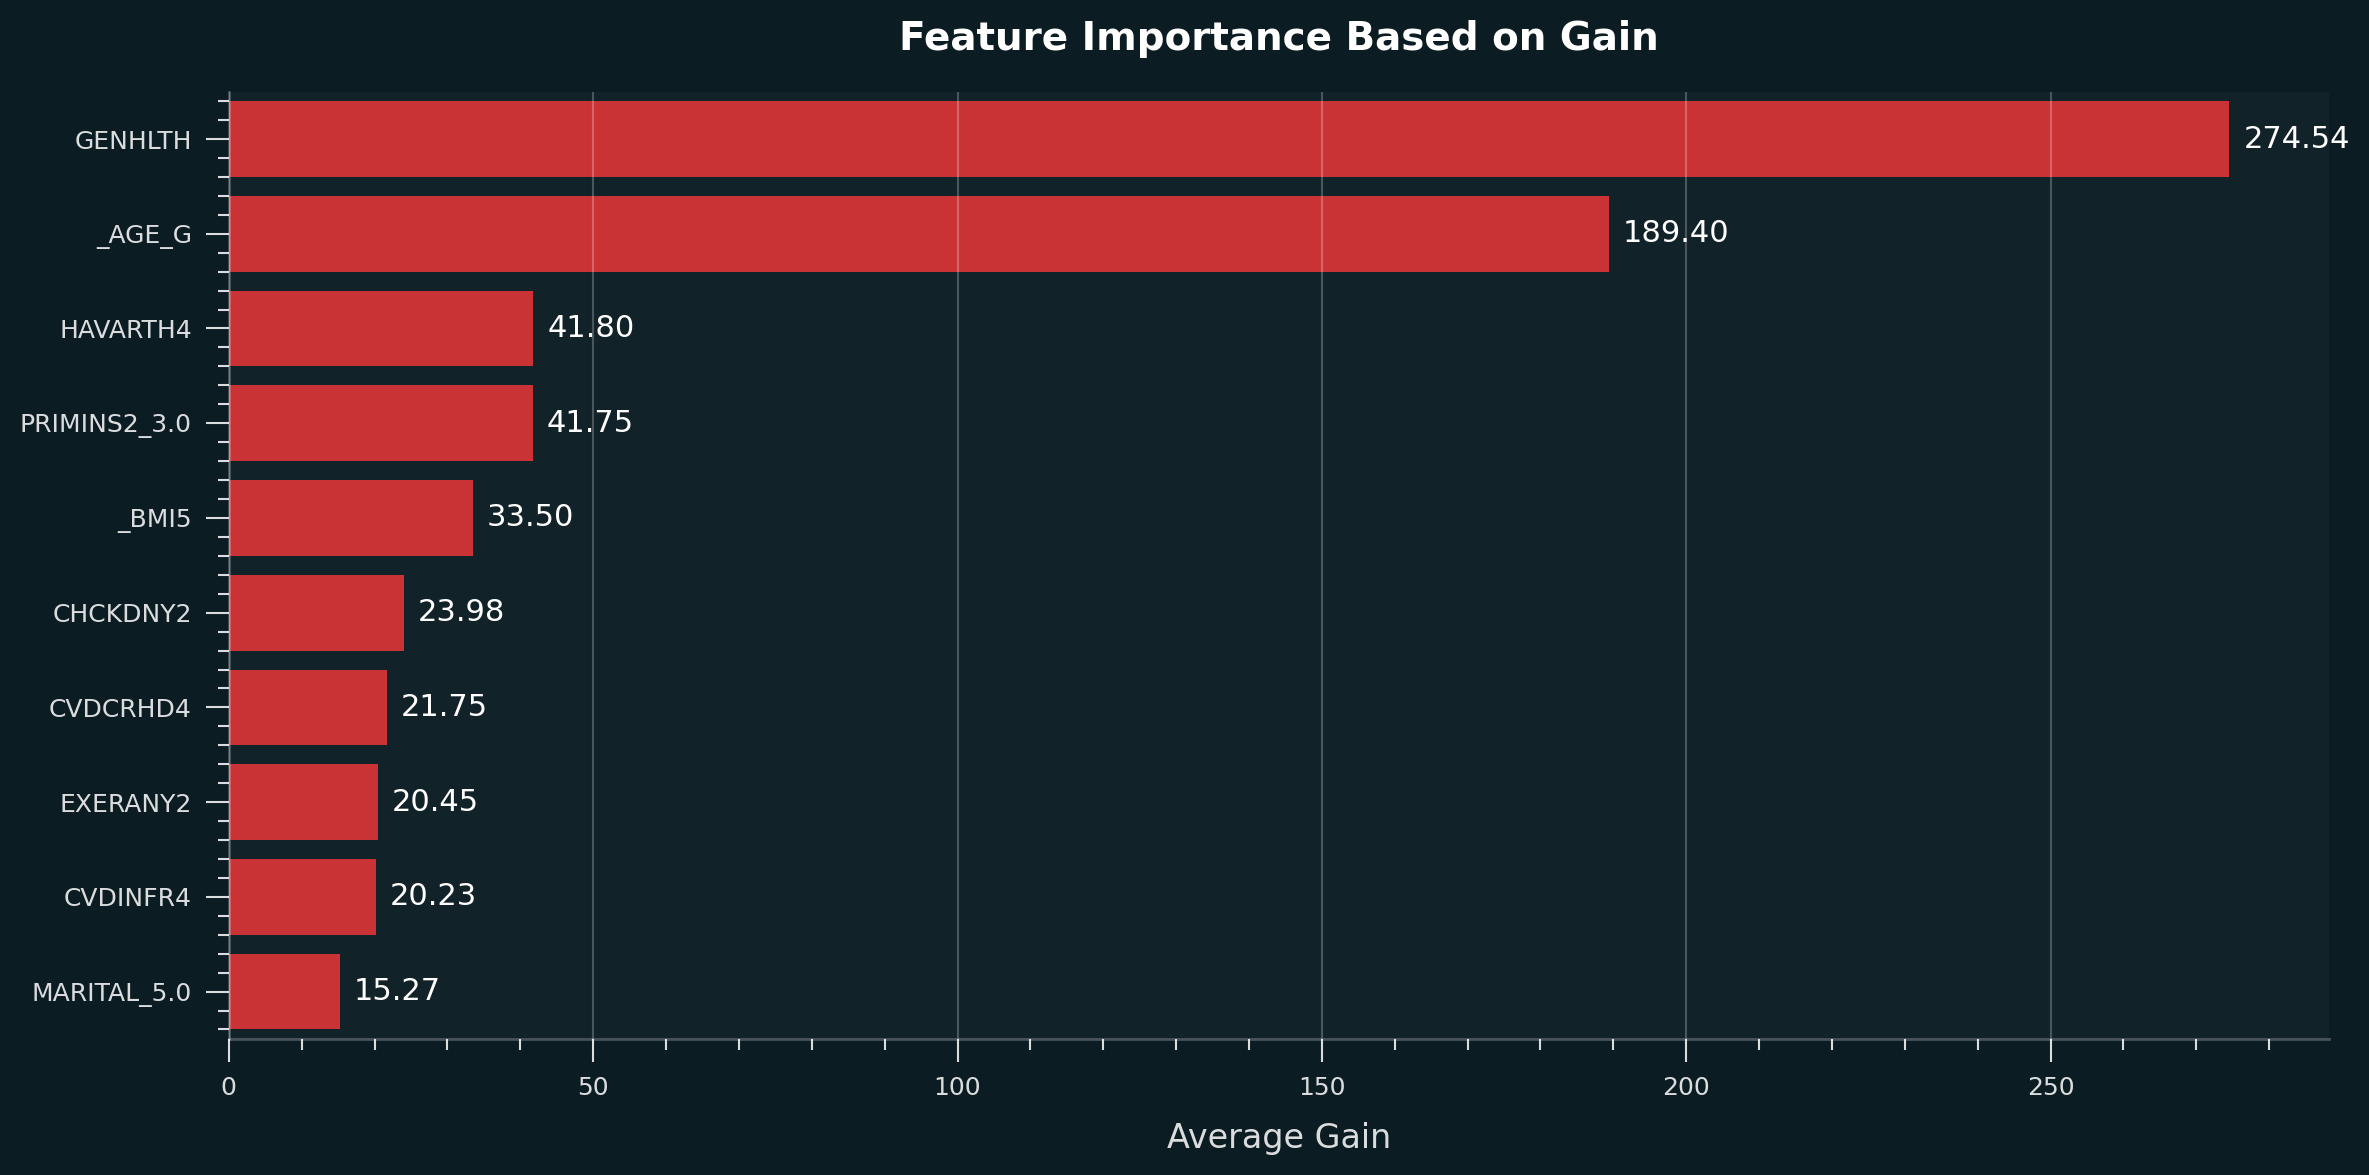

In [91]:
importance_dict = tuned_xgb_model.get_booster().get_score(importance_type='gain')

df_importance = pd.DataFrame(list(importance_dict.items()), columns=['Fitur', 'Gain'])

df_importance = df_importance.sort_values(by='Gain', ascending=False).head(10)

plt.figure(figsize=(12, 6))

ax = sns.barplot(x='Gain', y='Fitur', data=df_importance)

ax.bar_label(ax.containers[0], fmt='%.2f', padding=5, fontsize=11)

plt.title('Feature Importance Based on Gain', fontsize=14, fontweight='bold')
plt.xlabel('Average Gain', fontsize=12)
plt.ylabel('')
plt.tight_layout()
sns.despine()
plt.savefig(f"./outputs/modelling/xgb_feature_importance.png", dpi=300, transparent=True, bbox_inches='tight',pad_inches=0.1, format='png')

plt.show()

In [93]:
df_test['DIABETE4'].value_counts()

DIABETE4
0.0    75226
1.0    15423
Name: count, dtype: int64

In [96]:
df_diabete = df_test[df_test['DIABETE4'] == 1]

In [97]:
df_diabete

,_BMI5,_AGE_G,INCOME3,CVDINFR4,CVDCRHD4,ASTHMA3,CHCKDNY2,EDUCA,GENHLTH,EXERANY2,...,PRIMINS2_4.0,PRIMINS2_5.0,PRIMINS2_6.0,PRIMINS2_8.0,PRIMINS2_10.0,PRIMINS2_88.0,_SMOKER3_2.0,_SMOKER3_3.0,_SMOKER3_4.0,is_menthlth
213435,0.391130,6.0,9.0,0.0,0.0,1.0,0.0,4.0,4.0,1.0,...,False,False,False,False,False,False,False,False,True,0
242195,-0.152691,6.0,8.0,0.0,0.0,0.0,1.0,6.0,3.0,1.0,...,False,False,False,False,False,False,False,False,True,0
394080,-0.089729,6.0,8.0,0.0,0.0,0.0,0.0,6.0,3.0,1.0,...,False,False,False,False,False,False,False,False,True,0
105950,1.347848,6.0,7.0,0.0,0.0,0.0,0.0,6.0,3.0,1.0,...,False,False,False,False,False,False,False,False,True,0
141535,0.126587,5.0,7.0,1.0,0.0,0.0,0.0,5.0,3.0,1.0,...,False,False,False,False,False,False,False,False,True,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
168891,1.446910,6.0,7.0,0.0,1.0,0.0,1.0,6.0,4.0,1.0,...,False,False,False,False,False,False,False,False,True,0
451063,0.158994,5.0,7.0,0.0,0.0,0.0,0.0,5.0,2.0,0.0,...,False,False,False,False,False,False,True,False,False,1
395790,0.267402,6.0,5.0,0.0,0.0,0.0,0.0,3.0,1.0,0.0,...,False,False,False,False,False,False,False,False,True,0
139586,0.737592,6.0,5.0,1.0,1.0,1.0,0.0,5.0,1.0,0.0,...,False,False,False,False,False,False,False,True,False,1


In [98]:
fn_impact_map = {1: -17.0, 2: -14.0, 3: -11.0, 4: -8.0, 5: -5.0, 6: -2.5}

df_diabete['age impacted'] = df['_AGE_G'].map(fn_impact_map)

In [99]:
df_diabete['age impacted'].sum()

np.float64(-71987.5)